# Similarity Model

In this notebook we will try a different model architecture. Until this notebook we used (reranked) cosine distances for projected embeddings. Now, we construct a model that gets two image embeddings as input and outputs one logit for classification as similiar or not similiar.

We use the results from our previous notebooks for the baseline and new training pipeline:
- **Blurred backgrounds** (see [Background Interventions Notebook](01_background_interventions.ipynb))
- **DINOv3** backbone (see [Backbone Notebook](02_backbone.ipynb))
- Combined **ProxyAnchor + Center Loss** (see [Loss Combined Notebook](04_loss_combined.ipynb))
- **AdamW** optimizer (see [Optimizer Notebook](05_optimizers.ipynb))
- **OneCycleLR** scheduler (see [Scheduler Notebook](06_scheduler.ipynb))
- Class balancing via a generated samples (see [Class Balance Notebook](07_class_balance.ipynb))
- Configuration from best hyperparameter sweep run (see [Sweep Notebook](08b_sweep.ipynb))


## 1. Setup and Configuration

This section defines the required imports and configuration settings used throughout the notebook. These include library dependencies and any global parameters.

In [1]:
EXPERIMENT_NAME = "10_similarity_model"
RANDOM_SEED = 17 # 7, 17, 27, 37, 47

# -----------------------------
# Environment setup
# -----------------------------
import os
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

# -----------------------------
# Standard library imports
# -----------------------------
from dotenv import load_dotenv
from pathlib import Path
import random
import sys
import time

# -----------------------------
# Third-party libraries
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tabulate import tabulate
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
import wandb

import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# -----------------------------
# Project path setup
# -----------------------------
PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

# -----------------------------
# Local modules
# -----------------------------
from src.criterions import (
    CenterLoss,
    CombinedLoss,
    ProxyAnchorLoss,
)
from src.datasets import BlurImageDataset, EmbeddingDataset
from src.models import EmbeddingProjection
from src.training import train_loop
from src.utils import (
    create_deterministic_training_dataloader,
    get_device,
    set_seeds,
    extract_embeddings, get_embeddings,
)
from src.visualization import (
    plot_history,
    visualize_embeddings_mds,
    visualize_nearest_neighbors,
)

# -----------------------------
# Reproducibility
# -----------------------------
set_seeds(RANDOM_SEED)
print(f"PyTorch version: {torch.__version__}")

All random seeds set to 17 for reproducibility
PyTorch version: 2.9.1+cu128


Define shared paths for the whole project.

In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

In [3]:
# Configuration
config = {       
    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",
    "dinov3_input_size": 224,

    # Model
    "embedding_dim": 512,
    "hidden_dim": 768,
    "dropout": 0.1,
    
    # ProxyAnchor
    "proxyanchor_margin": 0.2,
    "proxyanchor_alpha": 16.0,
    "proxyanchor_lambda": 0.00001139770561131301,
    
    # AdamW
    "weight_decay": 0.00000655894766183814,
    "init_learning_rate": 0.00005403139355343448,
    
    # OneCycleLR
    "max_learning_rate": 0.007514589946885167,
    "pct_start": 0.2,

    # Training
    "batch_size": 32,
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Generate Augmentations
    "min_images_per_identity": 50,
    
    # Use higher batch size for similarity model to make training  faster
    "sim_batch_size": 512,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  dinov3_input_size: 224
  embedding_dim: 512
  hidden_dim: 768
  dropout: 0.1
  proxyanchor_margin: 0.2
  proxyanchor_alpha: 16.0
  proxyanchor_lambda: 1.139770561131301e-05
  weight_decay: 6.55894766183814e-06
  init_learning_rate: 5.403139355343448e-05
  max_learning_rate: 0.007514589946885167
  pct_start: 0.2
  batch_size: 32
  num_epochs: 200
  patience: 10
  val_split: 0.2
  min_images_per_identity: 50
  sim_batch_size: 512
  seed: 17


In [4]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project=os.getenv("WANDB_PROJECT", "jaguar-reid-karl-matti-schuetz"),
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


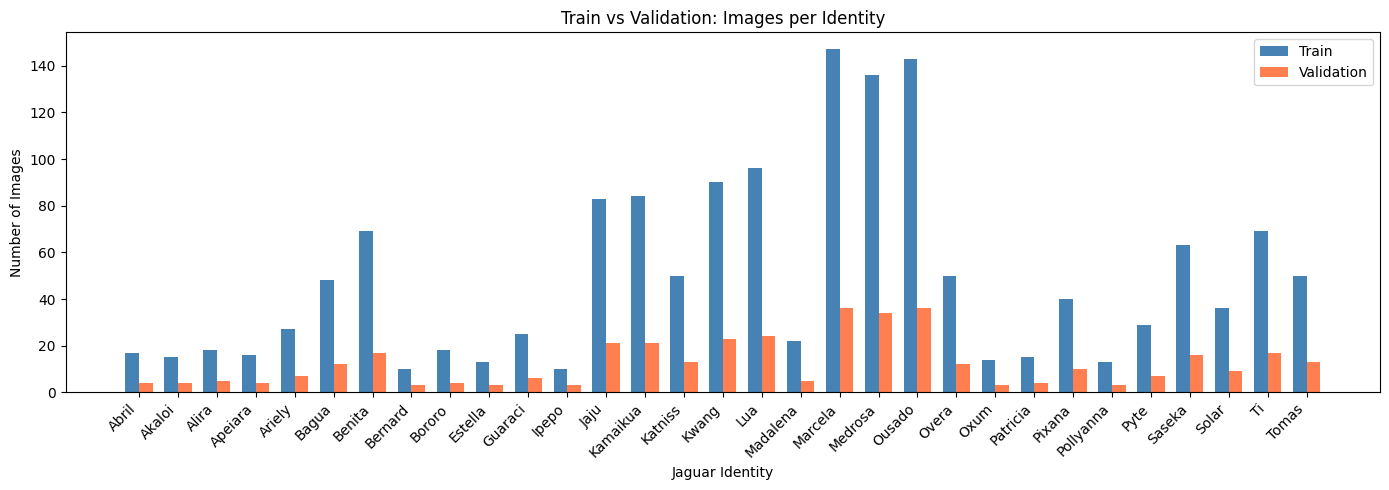


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [6]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [7]:
device = get_device()
print(f"Using device: {device}")

num_workers = min(8, os.cpu_count())
print(f"Using num_workers={num_workers} for DataLoader")

Using CUDA GPU
Using device: cuda
Using num_workers=8 for DataLoader


In [8]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = np.array([DATA_PATH / "train" / fn for fn in filenames])

train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [9]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")
    
wandb.log({
    "dino_num_params": dino_num_params,
    "dino_embedding_dim": dino_dim,
    "dino_input_size": dino_config["input_size"],
    "dino_preprocessing": str(dino_config),
})

Loading Dino model...


Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


We use the augmentations from the [Class Balance Notebook](07_class_balance.ipynb) to generate additional samples for underrepresented identities.

In [10]:
augment = transforms.Compose([
    # Randomly flip images horizontally; mimic different side of jaguar
    transforms.RandomHorizontalFlip(),

    # Crop and resize randomly to simulate different distances and framing
    transforms.RandomResizedCrop(dino_dim, scale=(0.85, 1.0)),

    # Small rotations to account for camera angle variation without distorting fur patterns
    transforms.RandomRotation(15),

    # Slight affine transformation: translation and scaling to simulate animal movement
    transforms.RandomAffine(
        degrees=0,           # no extra rotation
        translate=(0.05, 0.05),
        scale=(0.9, 1.1)
    ),

    # Subtle color changes to mimic lighting variation; avoid distorting natural fur
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.05
    ),

    # Apply slight blur to simulate motion blur or out-of-focus shots
    transforms.GaussianBlur(5, sigma=(0.1, 1.0)),
])

In [11]:
augment_dir = OUTPUT_PATH / "augmented_data"
os.makedirs(augment_dir, exist_ok=True)

train_image_paths = np.array(image_paths)[train_mask]

augmented_paths = []
augmented_labels = []

min_images_per_identity = config["min_images_per_identity"]

for label in tqdm(range(num_classes), desc="Augmenting classes"):

    mask = train_labels == label
    label_paths = train_image_paths[mask]
    needed = max(0, min_images_per_identity - len(label_paths))

    print(f"Class {label}: {len(label_paths)} samples, need {needed} more")

    for i in range(needed):

        img_path = random.choice(label_paths)
        filename = img_path.stem
        
        # Use filename to hinder data leakage from previous runs on validation set
        save_path = augment_dir / f"class{label}_aug_{filename}.png"

        img = Image.open(img_path).convert("RGBA")
        aug_img = augment(img)
        aug_img.save(save_path)

        augmented_paths.append(save_path)
        augmented_labels.append(label)

augmented_paths = np.array(augmented_paths)
augmented_labels = np.array(augmented_labels)

combined_train_paths = np.concatenate([train_image_paths, augmented_paths])
combined_train_labels = np.concatenate([train_labels, augmented_labels])

combined_train_filenames = np.array([p.name for p in combined_train_paths])

Augmenting classes:   0%|          | 0/31 [00:00<?, ?it/s]

Class 0: 17 samples, need 33 more


Augmenting classes:   3%|▎         | 1/31 [00:15<07:46, 15.55s/it]

Class 1: 15 samples, need 35 more


Augmenting classes:   6%|▋         | 2/31 [00:26<06:17, 13.00s/it]

...

Class 26: 29 samples, need 21 more


Augmenting classes:  87%|████████▋ | 27/31 [04:02<00:36,  9.03s/it]

Class 27: 63 samples, need 0 more
Class 28: 36 samples, need 14 more


Augmenting classes: 100%|██████████| 31/31 [04:08<00:00,  8.00s/it]

Class 29: 69 samples, need 0 more
Class 30: 50 samples, need 0 more


In [12]:
val_paths = np.array(image_paths)[~train_mask]
val_filenames = np.array([p.name for p in val_paths])

all_paths = np.concatenate([combined_train_paths, val_paths])
all_filenames = np.concatenate([combined_train_filenames, val_filenames])

all_labels = np.concatenate([combined_train_labels, val_labels])

image_dataset = BlurImageDataset(
    all_paths,
    preprocess_fn=dino_preprocess
)
image_loader = DataLoader(
    image_dataset,
    batch_size=32,
    num_workers=num_workers,
    shuffle=False,
    pin_memory=True,
)

print(f"Image DataLoader created with {len(image_loader)} batches")

Image DataLoader created with 76 batches


In [13]:
baseline_cache_path = OUTPUT_PATH / "dino_blur_embeddings_augmented.npz"

baseline_embeddings = get_embeddings(
    model=dino,
    cache_path=baseline_cache_path,
    data_loader=image_loader,
    filenames=all_filenames,
    device=device
)

Extracting embeddings for 76 images...


Extracting embeddings:   0%|          | 0/76 [00:00<?, ?it/s]

Extracting embeddings: 100%|██████████| 76/76 [10:29<00:00,  8.28s/it] 


Saved embeddings cache to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/10_similarity_model/dino_blur_embeddings_augmented.npz
Embeddings shape: (2409, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


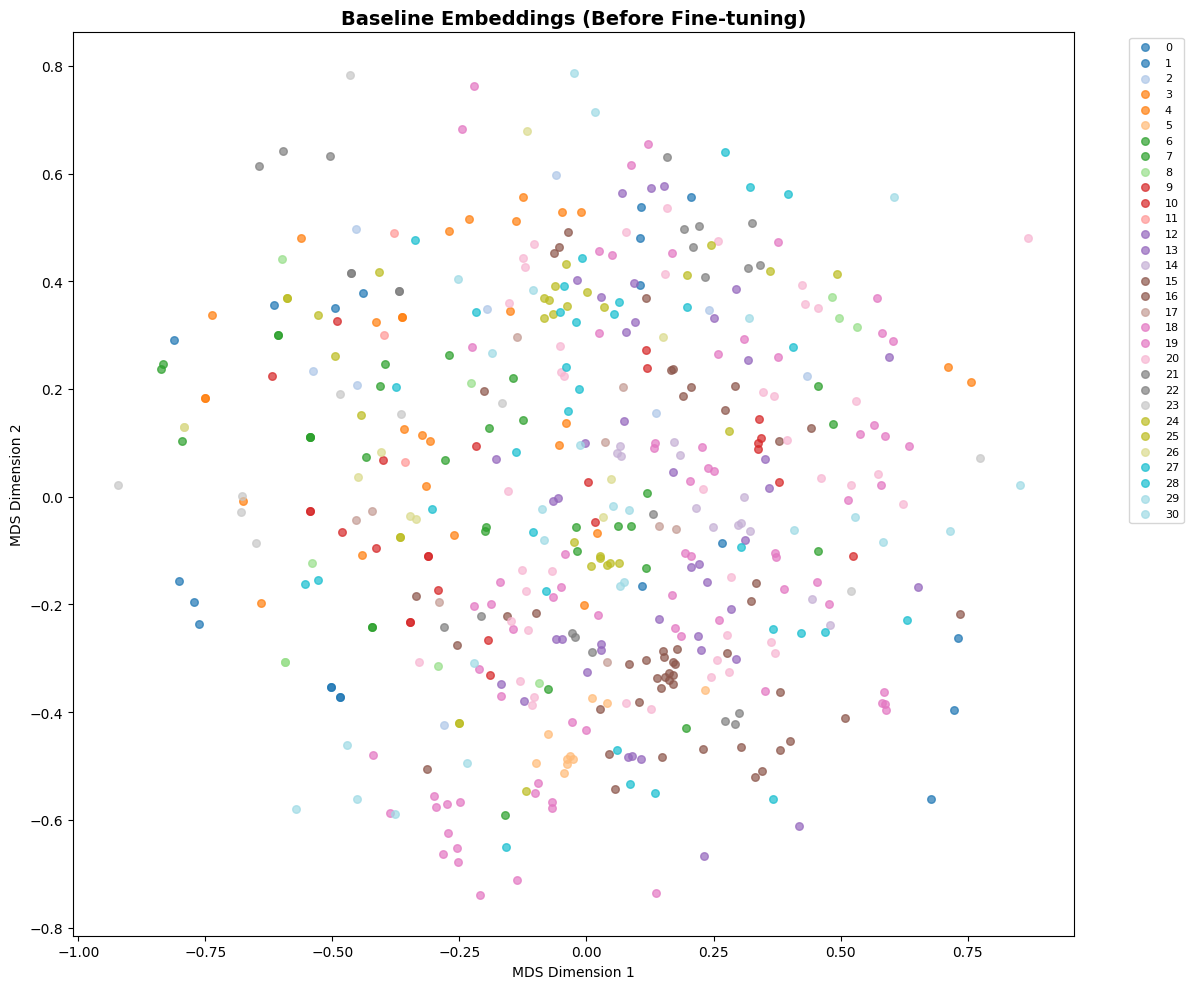

In [14]:
# Visualize DINO embeddings
fig = visualize_embeddings_mds(
    baseline_embeddings,
    all_labels,
    "Baseline Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "baseline_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig)})

In [15]:
table = [
    ["Scheduler", "Property", "Best epoch", "Training time"]
]

## Baseline

n the baseline approach, we retrain the model using the best configuration identified by the hyperparameter sweep.


In [16]:
# Train Dataset contains real and augmented images
baseline_emb_train_dataset = EmbeddingDataset(
    baseline_embeddings[:len(combined_train_paths)],
    combined_train_labels
)

baseline_emb_val_dataset = EmbeddingDataset(
    baseline_embeddings[len(combined_train_paths):],
    val_labels
)

baseline_emb_train_loader = create_deterministic_training_dataloader(
    baseline_emb_train_dataset,
    batch_size=config["batch_size"],
    seed=config['seed'],
    num_workers=num_workers,
    
)
baseline_emb_val_loader = DataLoader(
    baseline_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [17]:
# Create model
baseline_model = EmbeddingProjection(
    input_dim=dino_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

wandb.log({"num_projection_params": sum(p.numel() for p in baseline_model.parameters())})

baseline_model.print_model_summary()

Embedding Projection:
  Input dim: 768
  Hidden dim: 768
  Output dim: 512
  Dropout: 0.1
  Total parameters: 986880


In [18]:
criterion = CombinedLoss(
    first_loss=CenterLoss(
        num_classes=num_classes, 
        embedding_dim=config["embedding_dim"]
    ),
    second_loss=ProxyAnchorLoss(
        num_classes=num_classes, 
        embedding_dim=config["embedding_dim"], 
        margin=config["proxyanchor_margin"], 
        alpha=config["proxyanchor_alpha"]
    ),
    lambda_center=config["proxyanchor_lambda"]
).to(device)

print(f"Combined Loss: CenterLoss + ProxyAnchor")
print(f"  ProxyAnchor margin: {config['proxyanchor_margin']}")
print(f"  ProxyAnchor alpha: {config['proxyanchor_alpha']}")
print(f"  Lambda: {config['proxyanchor_lambda']}")

Combined Loss: CenterLoss + ProxyAnchor
  ProxyAnchor margin: 0.2
  ProxyAnchor alpha: 16.0
  Lambda: 1.139770561131301e-05


In [19]:
# Setup training components
optimizer = torch.optim.AdamW(
    list(baseline_model.parameters()) + list(criterion.parameters()),
    lr=config["init_learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=config["max_learning_rate"],
    epochs=config["num_epochs"],
    steps_per_epoch=len(baseline_emb_train_loader),
    pct_start=config["pct_start"],
    anneal_strategy='cos',
    cycle_momentum=False,
)

print("Training components initialized:")
print(f"  Optimizer: Adam (lr={config['init_learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: OneCycleLR (max_lr={config['max_learning_rate']}, epochs={config['num_epochs']}, steps_per_epoch={len(baseline_emb_train_loader)}, pct_start={config['pct_start']})")

Training components initialized:
  Optimizer: Adam (lr=5.403139355343448e-05, weight_decay=6.55894766183814e-06)
  Scheduler: OneCycleLR (max_lr=0.007514589946885167, epochs=200, steps_per_epoch=64, pct_start=0.2)


In [20]:
# Training loop
set_seeds(config['seed'])
baseline_checkpoint_path = CHECKPOINT_PATH / "best_model.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    baseline_model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="baseline_model",
    checkpoint_path=baseline_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_baseline": best_map,
    "best_epoch_baseline": best_epoch,
    "total_epochs_baseline": len(history['train_loss']),
    "training_time_baseline": training_time
})

table.append([
    "Baseline",
    f"{best_map} mAP",
    best_epoch,
    training_time
])

All random seeds set to 17 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/64 [00:00<?, ?it/s]

  Train Loss: 813.9858
  Val Loss:   571.0399
  Val mAP:    0.4231 | LR: 3.12e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 551.0102
  Val Loss:   416.2834
  Val mAP:    0.5384 | LR: 3.45e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 407.9462
  Val Loss:   311.8509
  Val mAP:    0.6298 | LR: 4.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 3.1220
  Val Loss:   4.8572
  Val mAP:    0.8927 | LR: 7.51e-03
  No improvement. Patience: 6/10

Epoch 41/200


  Train Loss: 2.8646
  Val Loss:   4.2420
  Val mAP:    0.8886 | LR: 7.51e-03
  No improvement. Patience: 7/10

Epoch 42/200


  Train Loss: 2.4303
  Val Loss:   3.6696
  Val mAP:    0.8861 | LR: 7.51e-03
  No improvement. Patience: 8/10

Epoch 43/200


  Train Loss: 2.0321
  Val Loss:   3.2113
  Val mAP:    0.8857 | LR: 7.51e-03
  No improvement. Patience: 9/10

Epoch 44/200


  Train Loss: 1.7902
  Val Loss:   2.7403
  Val mAP:    0.8816 | LR: 7.50e-03
  No improvement. Patience: 10/10

Early stopping triggered after 44 epochs

Training complete!
Best epoch: 34, Val mAP: 0.9036


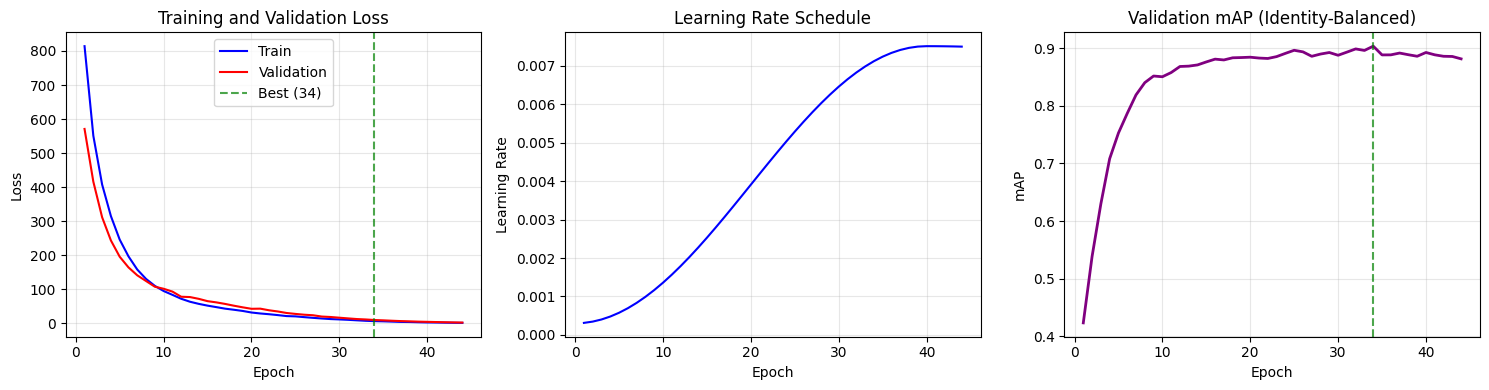

In [21]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_baseline": wandb.Image(fig)})

In [22]:
# Load best model
checkpoint = torch.load(baseline_checkpoint_path, map_location=device, weights_only=False)
baseline_model.load_state_dict(checkpoint['model_state_dict'])
baseline_model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 34
  Val Loss: 10.2345
  Val mAP: 0.9036


In [23]:
# Extract fine-tuned embeddings for training data
baseline_model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = baseline_model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (2409, 512)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


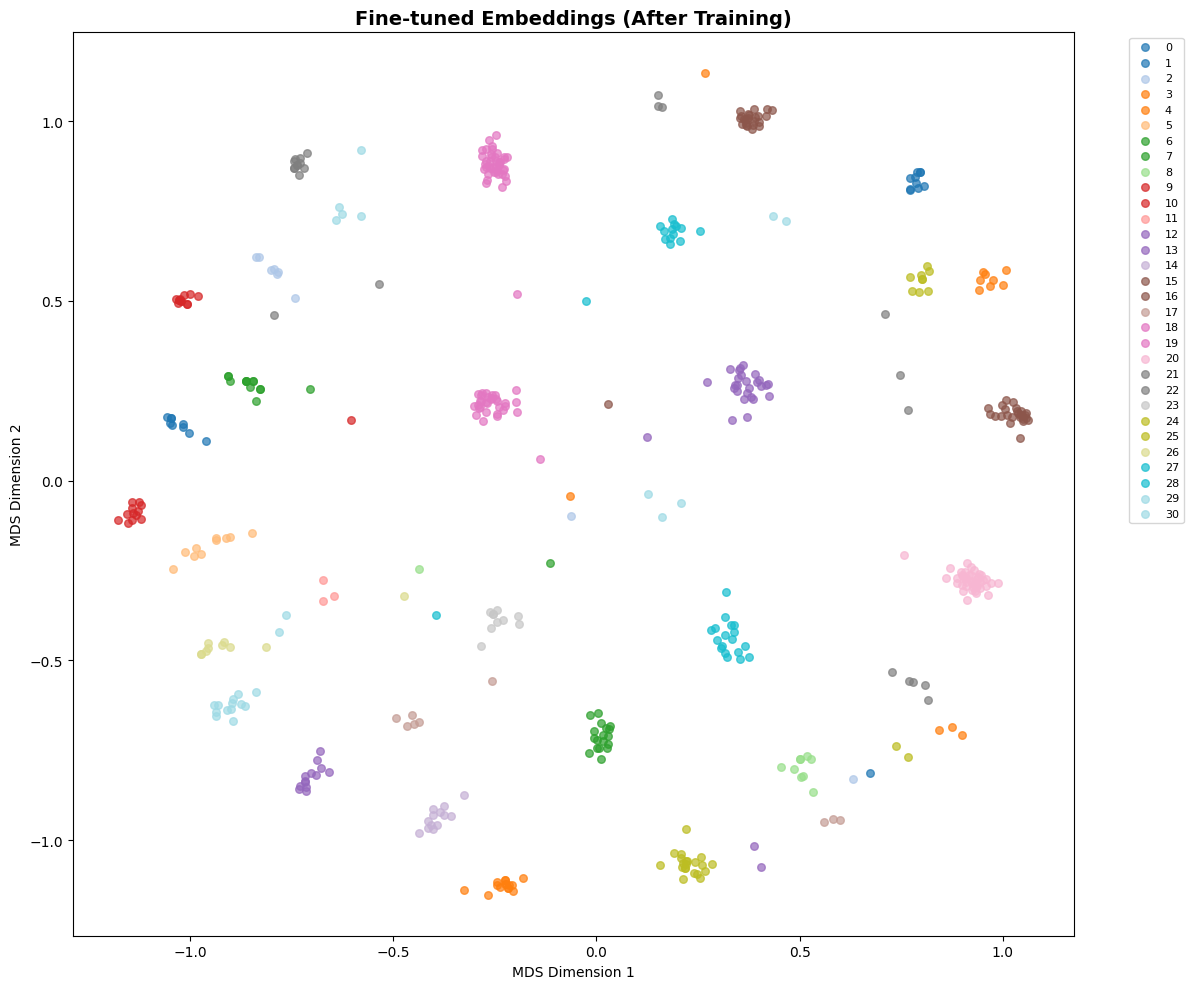

In [24]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    all_labels,
    "Fine-tuned Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds": wandb.Image(fig_finetuned)})

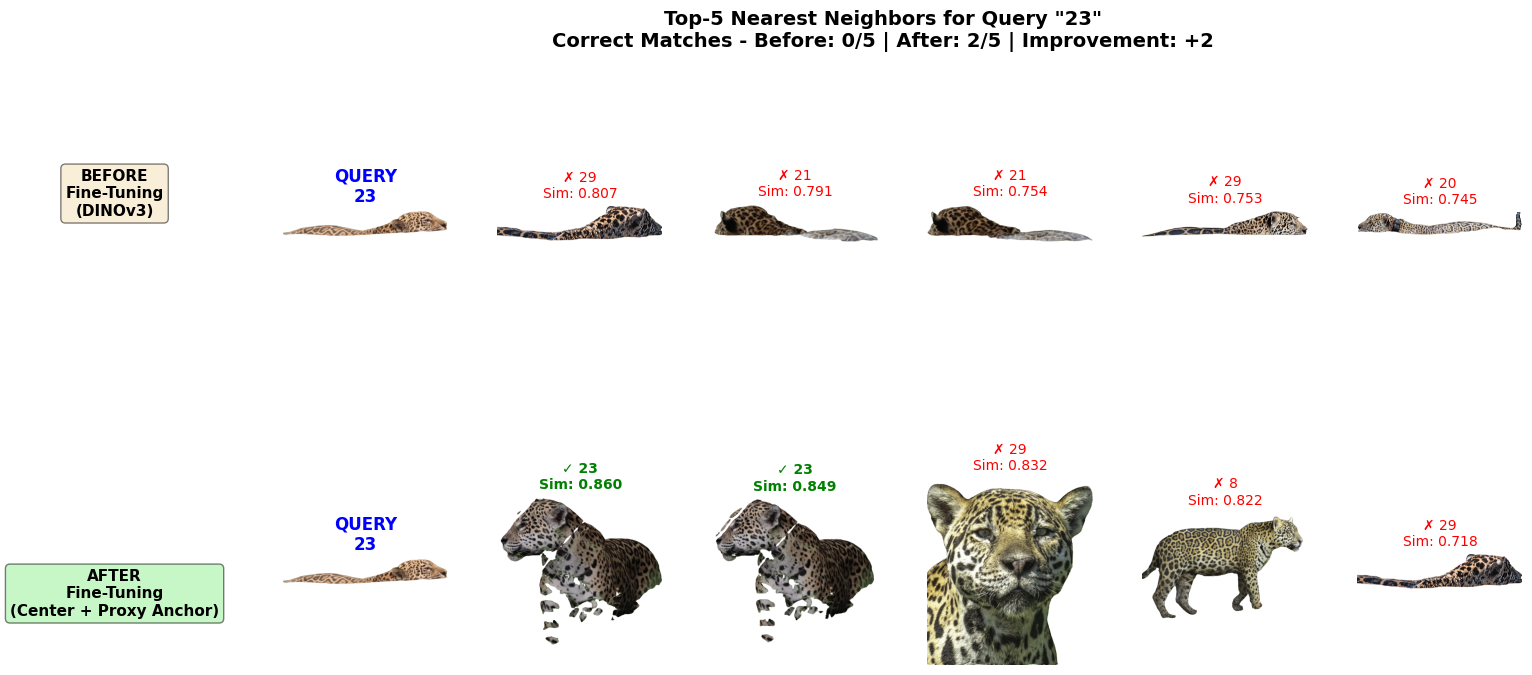

In [25]:
random_idx = np.random.randint(0, len(val_labels))
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[len(combined_train_paths):],
    finetuned_embeddings=finetuned_embeddings[len(combined_train_paths):],
    image_paths=all_paths[len(combined_train_paths):],
    labels=val_labels,
    before_label='BEFORE\nFine-Tuning\n(DINOv3)',
    after_label='AFTER\nFine-Tuning\n(Center + Proxy Anchor)'
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_baseline.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_baseline": wandb.Image(fig),
    "nearest_neighbors_stats_baseline": stats,
})


In [26]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Similarity Model

The similarity model takes two embeddings as input and outputs a single logit representing their similarity. Consequently, the training pipeline must be adapted to operate on image pairs rather than individual samples.

For this experiment, we generate all possible combinations of training images to form pairs. This approach greatly increases the number of training samples but also amplifies class imbalance, as negative pairs grow much faster than positive pairs. To address this, we apply weighting to positive pairs during training.

To keep the comparison consistent with the baseline, we use the same hyperparameter configuration as in the baseline model. However, additional experiments will be required to identify more suitable pair sampling strategies and hyperparameters for this model architecture.

Instead of evaluating the model using mAP on the validation set, we track the prediction accuracy as the primary validation metric.

We weight positive pairs by the ratio of total negative pairs to total positive pairs, helping to balance their influence during training.


In [27]:
unique, counts = np.unique(labels, return_counts=True)
print(f"Counts per class: {dict(zip(unique, counts))}")

pos_pairs = np.sum(counts * (counts - 1) // 2)
print(f"Total positive pairs: {pos_pairs}")

total_images = len(labels)
total_pairs = total_images * (total_images - 1) // 2
print(f"Total pairs: {total_pairs}")

neg_pairs = total_pairs - pos_pairs
print(f"Total negative pairs: {neg_pairs}")

pos_weight = neg_pairs / pos_pairs
print(f"Positive class weight: {pos_weight:.4f}")

pos_acc_weight = pos_pairs / total_pairs
neg_acc_weight = neg_pairs / total_pairs
print(f"Positive class accuracy weight: {pos_acc_weight:.4f}")
print(f"Negative class accuracy weight: {neg_acc_weight:.4f}")

Counts per class: {np.int64(0): np.int64(21), np.int64(1): np.int64(19), np.int64(2): np.int64(23), np.int64(3): np.int64(20), np.int64(4): np.int64(34), np.int64(5): np.int64(60), np.int64(6): np.int64(86), np.int64(7): np.int64(13), np.int64(8): np.int64(22), np.int64(9): np.int64(16), np.int64(10): np.int64(31), np.int64(11): np.int64(13), np.int64(12): np.int64(104), np.int64(13): np.int64(105), np.int64(14): np.int64(63), np.int64(15): np.int64(113), np.int64(16): np.int64(120), np.int64(17): np.int64(27), np.int64(18): np.int64(183), np.int64(19): np.int64(170), np.int64(20): np.int64(179), np.int64(21): np.int64(62), np.int64(22): np.int64(17), np.int64(23): np.int64(19), np.int64(24): np.int64(50), np.int64(25): np.int64(16), np.int64(26): np.int64(36), np.int64(27): np.int64(79), np.int64(28): np.int64(45), np.int64(29): np.int64(86), np.int64(30): np.int64(63)}
Total positive pairs: 95171
Total pairs: 1794565
Total negative pairs: 1699394
Positive class weight: 17.8562
Positi

In [28]:
def sim_train_epoch(model, loader, criterion, optimizer, scheduler, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total = 0
    correct = 0
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for embedding, matchs in pbar:
        embedding = embedding.to(device)
        matchs = matchs.unsqueeze(1).to(device)

        # Forward pass
        pred = model(embedding)
        loss = criterion(pred, matchs)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # If OneCycleLR, step per batch
        if isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
            scheduler.step()
        
        # Metrics
        total_loss += loss.item()
        pred_sigmoid = torch.sigmoid(pred) >= 0.5
        correct_mask = (pred_sigmoid == matchs).float()
        weights = torch.where(matchs == 1, pos_acc_weight, neg_acc_weight)
        correct += (correct_mask * weights).sum().item()
        total += matchs.size(0)
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def sim_validate_epoch(model, loader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    total_loss = 0
    total = 0
    correct = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation', leave=False)
        for embeddings, matchs in pbar:
            embeddings = embeddings.to(device)
            matchs = matchs.unsqueeze(1).to(device)

            pred = model(embeddings)
            loss = criterion(pred, matchs)

            total_loss += loss.item()
            pred_sigmoid = torch.sigmoid(pred) >= 0.5
            correct_mask = (pred_sigmoid == matchs).float()
            weights = torch.where(matchs == 1, pos_acc_weight, neg_acc_weight)
            correct += (correct_mask * weights).sum().item()
            total += matchs.size(0)

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def sim_train_loop(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        scheduler,
        device,
        name,
        checkpoint_path,
        num_epochs,
        patience,
        classes,
    ):
        
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'val_map': [], 'lr': []
    }

    best_val_acc = 0.0
    patience_counter = 0
    best_epoch = 0

    print(f"Starting training for {num_epochs} epochs...")
    print("=" * 70)

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        # Train
        train_loss, train_acc = sim_train_epoch(model, train_loader, criterion, optimizer, scheduler, device)
        
        # Validate
        val_loss, val_acc = sim_validate_epoch(model, val_loader, criterion, device)
        
        # Update scheduler
        if not isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        # Log to W&B
        wandb.log({
            'model': name,
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'learning_rate': current_lr,
        })
        
        # Print summary
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Train Acc:  {train_acc:.4f}")
        print(f"  Val Loss:   {val_loss:.4f}")
        print(f"  Val Acc:    {val_acc:.4f} | LR: {current_lr:.2e}")
        
        # Checkpoint best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            patience_counter = 0

            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
                'num_epochs': num_epochs,
                'patience': patience,
                'label_encoder_classes': classes,
                'num_classes': len(classes),
                'name': name
            }, checkpoint_path)
            
            print(f"  [New best model saved]")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience: {patience_counter}/{patience}")

        # Early stopping
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

    print("\n" + "=" * 70)
    print(f"Training complete!")
    print(f"Best epoch: {best_epoch}, Val Acc: {best_val_acc:.4f}")

    return history, best_val_acc, best_epoch


This dataset returns all possible pairs of images from the training set. Each sample consists of the concatenated embeddings of the two images along with their corresponding labels.

In [29]:
class ContrastiveDataset(torch.utils.data.Dataset):
    def __init__(self, embeddings, labels, transform=None):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.FloatTensor(labels)
        self.transform = transform

        self.n = len(self.embeddings)

    def __len__(self):
        return self.n ** 2

    def __getitem__(self, idx):
        # Determine anchor and positive/negative pairs
        anchor_idx = idx // self.n
        pos_neg_idx = idx % self.n

        query_image = self.embeddings[anchor_idx]
        query_label = self.labels[anchor_idx]

        gallery_image = self.embeddings[pos_neg_idx]
        gallery_label = self.labels[pos_neg_idx]

        if self.transform:
            query_image = self.transform(query_image)
            gallery_image = self.transform(gallery_image)
        
        combined_embedding = torch.cat([query_image, gallery_image], dim=0)
        match_label = (query_label == gallery_label).float()
        return combined_embedding, match_label


In [30]:
sim_emb_train_dataset = ContrastiveDataset(
    baseline_embeddings[:len(combined_train_paths)],
    combined_train_labels
)

sim_emb_val_dataset = ContrastiveDataset(
    baseline_embeddings[len(combined_train_paths):],
    val_labels
)

sim_emb_train_loader = create_deterministic_training_dataloader(
    sim_emb_train_dataset,
    batch_size=config["sim_batch_size"],
    seed=config['seed'],
    num_workers=num_workers,

)
sim_emb_val_loader = DataLoader(
    sim_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [31]:
# Create model
sim_model = EmbeddingProjection(
    input_dim=dino_dim * 2,  # Concatenated query and gallery embeddings
    hidden_dim=config["hidden_dim"],
    output_dim=1,  # Binary classification (match vs non-match)
    dropout=config["dropout"],
).to(device)

wandb.log({"num_params_similarity_model": sum(p.numel() for p in sim_model.parameters())})

sim_model.print_model_summary()

Embedding Projection:
  Input dim: 1536
  Hidden dim: 768
  Output dim: 1
  Dropout: 0.1
  Total parameters: 1182723


In [32]:
# Setup training components
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)).to(device)

optimizer = torch.optim.AdamW(
    list(sim_model.parameters()) + list(criterion.parameters()),
    lr=config["init_learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=config["max_learning_rate"],
    epochs=config["num_epochs"],
    steps_per_epoch=len(sim_emb_train_loader),
    pct_start=config["pct_start"],
    anneal_strategy='cos',
    cycle_momentum=False,
)

print("Training components initialized:")
print(f"  Loss: BCEWithLogitsLoss")
print(f"  Optimizer: Adam (lr={config['init_learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: OneCycleLR (max_lr={config['max_learning_rate']}, epochs={config['num_epochs']}, pct_start={config['pct_start']})")

Training components initialized:
  Loss: BCEWithLogitsLoss
  Optimizer: Adam (lr=5.403139355343448e-05, weight_decay=6.55894766183814e-06)
  Scheduler: OneCycleLR (max_lr=0.007514589946885167, epochs=200, pct_start=0.2)


In [33]:
# Training loop
set_seeds(config['seed'])
sim_checkpoint_path = CHECKPOINT_PATH / "best_similarity_model.pth"
start_time = time.time()
history, best_acc, best_epoch = sim_train_loop(
    sim_model, 
    sim_emb_train_loader, 
    sim_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="similarity_model",
    checkpoint_path=sim_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_acc_similarity_model": best_acc,
    "best_epoch_similarity_model": best_epoch,
    "total_epochs_similarity_model": len(history['train_loss']),
    "training_time_similarity_model": training_time
})

table.append([
    "Similarity Model",
    f"{best_acc:.4f}% (Acc)",
    best_epoch,
    training_time
])

All random seeds set to 17 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 0.4431
  Train Acc:  77.5443
  Val Loss:   0.3191
  Val Acc:    86.2346 | LR: 3.12e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 0.0916
  Train Acc:  90.4558
  Val Loss:   0.2916
  Val Acc:    88.9971 | LR: 3.45e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 0.0277
  Train Acc:  91.0926
  Val Loss:   0.3445
  Val Acc:    89.3425 | LR: 4.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 0.0164
  Train Acc:  91.1256
  Val Loss:   0.3883
  Val Acc:    89.3313 | LR: 4.77e-04
  No improvement. Patience: 1/10

Epoch 5/200


...

  Train Loss: 0.0124
  Train Acc:  91.0729
  Val Loss:   0.7564
  Val Acc:    89.5510 | LR: 1.57e-03
  No improvement. Patience: 6/10

Epoch 12/200


  Train Loss: 0.0125
  Train Acc:  91.0739
  Val Loss:   0.6065
  Val Acc:    89.3635 | LR: 1.79e-03
  No improvement. Patience: 7/10

Epoch 13/200


  Train Loss: 0.0128
  Train Acc:  91.0714
  Val Loss:   0.6384
  Val Acc:    89.2914 | LR: 2.02e-03
  No improvement. Patience: 8/10

Epoch 14/200


  Train Loss: 0.0111
  Train Acc:  91.1012
  Val Loss:   0.6858
  Val Acc:    89.4833 | LR: 2.27e-03
  No improvement. Patience: 9/10

Epoch 15/200


  Train Loss: 0.0112
  Train Acc:  91.1022
  Val Loss:   0.6980
  Val Acc:    89.4891 | LR: 2.53e-03
  No improvement. Patience: 10/10

Early stopping triggered after 15 epochs

Training complete!
Best epoch: 5, Val Acc: 89.5824


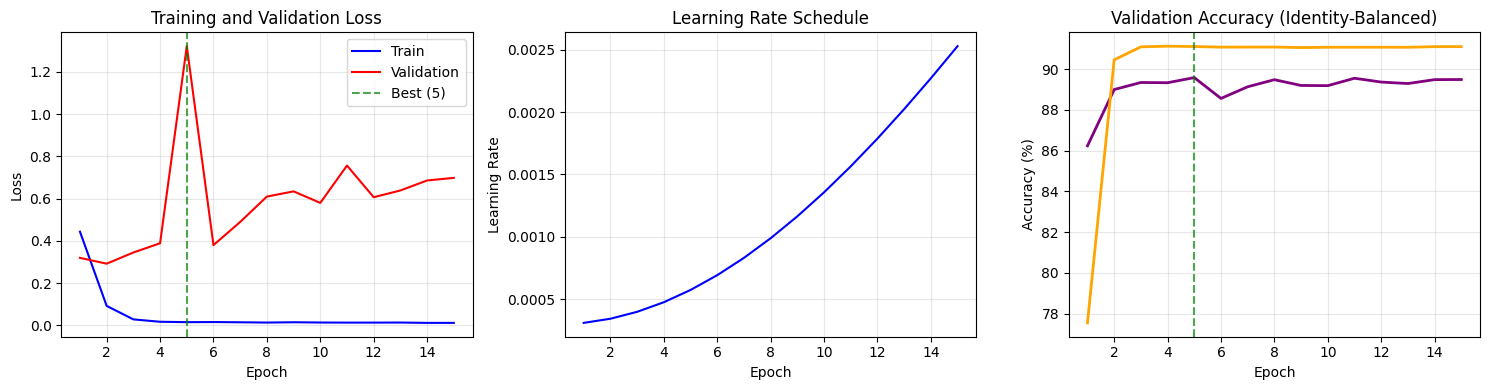

In [34]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Validation')
axes[0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LR
axes[1].plot(epochs_range, history['lr'], 'b-')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Learning Rate Schedule')
axes[1].grid(True, alpha=0.3)

# Acc
axes[2].plot(epochs_range, history['val_acc'], 'purple', linewidth=2)
axes[2].plot(epochs_range, history['train_acc'], 'orange', linewidth=2)
axes[2].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_title('Validation Accuracy (Identity-Balanced)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CHECKPOINT_PATH / 'training_curves_similarity_model.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_similarity_model": wandb.Image(fig)})

In [35]:
# Load best model
checkpoint = torch.load(sim_checkpoint_path, map_location=device, weights_only=False)
sim_model.load_state_dict(checkpoint['model_state_dict'])
sim_model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val Acc: {checkpoint['val_acc']:.4f}")

Loaded best model from epoch 5
  Val Loss: 1.3219
  Val Acc: 89.5824


In [36]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Summary

In [37]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+---------------+------------------------+--------------------+
| Scheduler     | Baseline               | Similarity Model   |
+===============+========================+====================+
| Property      | 0.9036138762639451 mAP | 89.5824% (Acc)     |
+---------------+------------------------+--------------------+
| Best epoch    | 34                     | 5                  |
+---------------+------------------------+--------------------+
| Training time | 92.46472597122192      | 1219.8089725971222 |
+---------------+------------------------+--------------------+


In [38]:
# create df from table and log to W&B
df = pd.DataFrame(table[1:], columns=table[0])
print(df)

wandb.log({"experiment_summary": wandb.Table(dataframe=df)})

          Scheduler                Property  Best epoch  Training time
0          Baseline  0.9036138762639451 mAP          34      92.464726
1  Similarity Model          89.5824% (Acc)           5    1219.808973


## Submission

In [39]:
submission_model = "sim"

if submission_model != "baseline" and submission_model != "sim":
    raise ValueError(f"Invalid submission model: {submission_model}")

wandb.log({"submission_type": submission_model})

In [40]:
model = baseline_model if submission_model == "baseline" else sim_model
checkpoint_path = baseline_checkpoint_path if submission_model == "baseline" else sim_checkpoint_path
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

EmbeddingProjection(
  (network): Sequential(
    (0): Linear(in_features=1536, out_features=768, bias=True)
    (1): BatchNorm1d(768, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=768, out_features=1, bias=True)
    (5): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

In [41]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(DATA_PATH / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [42]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [DATA_PATH / "test" / filename for filename in test_images]

test_loader = DataLoader(
    BlurImageDataset(
        test_image_paths,
        preprocess_fn=dino_preprocess
    ),
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

# Extract embeddings for test images
print(f"\nExtracting embeddings for test images...")
test_embeddings = extract_embeddings(
    model=dino,
    data_loader=test_loader,
    device=device,
    desc="Test embeddings"
)

print(f"Test embeddings shape: {test_embeddings.shape}")

Unique test images: 371

Extracting embeddings for test images...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Test embeddings: 100%|██████████| 12/12 [02:03<00:00, 10.28s/it]

Test embeddings shape: (371, 768)


In [43]:
if submission_model == "baseline":
    # Project through fine-tuned model
    model.eval()
    with torch.no_grad():
        test_tensor = torch.FloatTensor(test_embeddings).to(device)
        test_finetuned_embeddings = model(test_tensor).cpu().numpy()
        test_finetuned_embeddings = test_finetuned_embeddings / np.linalg.norm(test_finetuned_embeddings, axis=1, keepdims=True)

    print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
    print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")

    # Create mapping from filename to embedding
    img_to_embedding = {
        filename: embedding 
        for filename, embedding in zip(test_images, test_finetuned_embeddings)
    }

In [44]:
# Compute similarity for each pair
img_to_index = {filename: idx for idx, filename in enumerate(test_images)}

print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_id = img_to_index[row['query_image']]
    gallery_id = img_to_index[row['gallery_image']]
    
    if submission_model == "baseline":
        query_emb = img_to_embedding[row['query_image']]
        gallery_emb = img_to_embedding[row['gallery_image']]
        
        # Cosine similarity (embeddings are already normalized)
        sim = np.dot(query_emb, gallery_emb)
        similarities.append(sim)
    else:
        query_embedding = test_embeddings[query_id]
        gallery_embedding = test_embeddings[gallery_id]

        combined_embedding = np.concatenate([query_embedding, gallery_embedding])
        combined_embedding_tensor = torch.from_numpy(combined_embedding).float().to(device)
        # with torch.no_grad():
        #     pred = torch.sigmoid(model(combined_embedding_tensor))
        pred = model(combined_embedding_tensor.unsqueeze(0))
        similarity = pred.item()
        similarities.append(similarity)

# Clip to [0, 1] range
similarities = np.array(similarities)
# similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

Computing pairwise similarities...


Computing similarities: 100%|██████████| 137270/137270 [01:53<00:00, 1206.67it/s]


Similarity statistics:
  Min: -29.3954
  Max: 12.6866
  Mean: -10.8718
  Std: 4.5124


In [45]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(DATA_PATH / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Submission DataFrame:
   row_id  similarity
0       0   -1.236543
1       1   -8.472015
2       2   -5.295935
3       3   -8.807490
4       4   -6.658442
5       5  -13.779318
6       6   -9.271496
7       7   -8.934546
8       8   -5.115739
9       9  -10.932631

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [46]:
# Save submission
submission_path = OUTPUT_PATH / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/10_similarity_model/submission.csv
File size: 3439.0 KB


## Artifacts

In [47]:
# Save model as W&B artifact
base_model_artifact = wandb.Artifact(
    name=f"baseline-model",
    type="model",
    description="Center + ProxyAnchor fine-tuned MegaDescriptor model for jaguar re-identification"
)
base_model_artifact.add_file(baseline_checkpoint_path)
wandb.log_artifact(base_model_artifact)

sim_model_artifact = wandb.Artifact(
    name=f"similarity-model",
    type="model",
    description="Similarity Model for jaguar re-identification"
)
sim_model_artifact.add_file(sim_checkpoint_path)
wandb.log_artifact(sim_model_artifact)

print("Model artifacts saved to W&B")

Model artifacts saved to W&B


In [48]:
# Save submission as W&B artifact
submission_artifact = wandb.Artifact(
    name="submission",
    type="submission",
    description=f"Competition submission file for {submission_model} loss"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Submission artifact saved to W&B")

Submission artifact saved to W&B


In [49]:
wandb.finish()

best_epoch_baseline,▁
best_epoch_similarity_model,▁
dino_embedding_dim,▁
dino_num_params,▁
epoch,▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇███▁▂▂▂▂▂▃▃▃▃
final_val_acc_similarity_model,▁
final_val_mAP_baseline,▁
learning_rate,▁▁▁▁▁▂▂▂▂▂▃▃▃▄▅▅▆▆▆▆▇▇▇▇████████▁▁▁▁▁▂▃▃
num_identities,▁
num_params_similarity_model,▁
+11,...
